In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
DATA_PATH = '../data/raw/cfpb_data.csv'
df = pd.read_csv(DATA_PATH)
print (f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Data loaded successfully!
Shape: 9,609,797 rows and 18 columns
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [4]:
print ("Fisrt 5 rows of data")
df.head()

Fisrt 5 rows of data


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [5]:
# Count missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Count', ascending=False)

print("📊 Missing Values Summary:")
print(missing_summary[missing_summary['Missing Count'] > 0])

# Specifically check the narrative column
narrative_missing = df['Consumer complaint narrative'].isnull().sum()
print(f"\n📝 Consumer complaint narrative missing: {narrative_missing:,} ({narrative_missing/len(df)*100:.2f}%)")

📊 Missing Values Summary:
                              Missing Count  Missing Percentage
Tags                                8981029           93.457011
Consumer disputed?                  8841498           92.005044
Consumer complaint narrative        6629041           68.982113
Company public response             4770207           49.638999
Consumer consent provided?          1649561           17.165409
Sub-issue                            839522            8.736105
Sub-product                          235295            2.448491
State                                 54516            0.567296
ZIP code                              30228            0.314554
Company response to consumer             20            0.000208
Issue                                     6            0.000062

📝 Consumer complaint narrative missing: 6,629,041 (68.98%)


📊 Product Distribution (Cleaned):
                                                      Count  Percentage
Product_clean                                                          
credit reporting or other personal consumer rep...  4834855   50.311729
credit reporting, credit repair services, or ot...  2163857   22.517198
debt collection                                      799197    8.316482
Credit card                                          433055    4.506391
mortgage                                             422254    4.393995
Savings account                                      291178    3.030012
Money transfer                                       150420    1.565278
credit reporting                                     140429    1.461311
student loan                                         109717    1.141720
bank account or service                               86205    0.897053
vehicle loan or lease                                 72957    0.759194
Personal loan                 

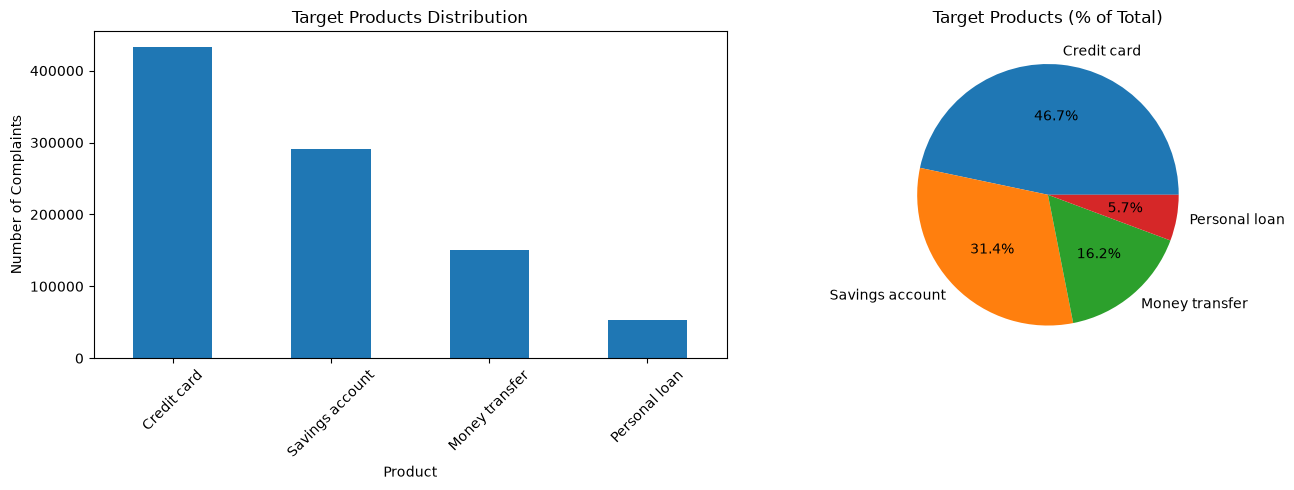


📊 Summary:
   Total complaints: 9,609,797
   Target products: 927,349 (9.65%)
   Removed: 8,682,448 complaints


In [7]:
# First, let's clean up product names
def clean_product_name(product):
    """
    Standardize product names to match our target products
    """
    if pd.isna(product):
        return product
    
    product = str(product).lower()
    
    # Credit Card products
    if 'credit card' in product:
        return 'Credit card'
    
    # Personal Loan products
    if 'payday loan' in product or 'personal loan' in product:
        return 'Personal loan'
    
    # Savings Account products
    if 'savings' in product or 'checking' in product:
        return 'Savings account'
    
    # Money Transfer products
    if 'money transfer' in product or 'money service' in product:
        return 'Money transfer'
    
    # If not a target product, return as-is
    return product

# Apply the cleaning
df['Product_clean'] = df['Product'].apply(clean_product_name)

# Now count by cleaned product names
product_counts = df['Product_clean'].value_counts()
product_percentage = (product_counts / len(df)) * 100

# Create summary
product_summary = pd.DataFrame({
    'Count': product_counts,
    'Percentage': product_percentage
})
print("📊 Product Distribution (Cleaned):")
print(product_summary)

# Filter to our target products only
target_products = ['Credit card', 'Personal loan', 'Savings account', 'Money transfer']
df_filtered = df[df['Product_clean'].isin(target_products)]

print(f"\n✅ Filtered to {len(df_filtered):,} complaints for target products")
print(f"📊 Target Product Distribution:")
print(df_filtered['Product_clean'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target products only
target_counts = df_filtered['Product_clean'].value_counts()
target_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Target Products Distribution')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart of target products
target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Target Products (% of Total)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Show what we filtered out
print(f"\n📊 Summary:")
print(f"   Total complaints: {len(df):,}")
print(f"   Target products: {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.2f}%)")
print(f"   Removed: {len(df) - len(df_filtered):,} complaints")

In [8]:
# Check missing values in the filtered dataset
missing_values = df_filtered.isnull().sum()
missing_percentage = (missing_values / len(df_filtered)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Count', ascending=False)

print(" Missing Values Summary (Filtered Data):")
print(missing_summary[missing_summary['Missing Count'] > 0])

# Specifically check the narrative column
narrative_missing = df_filtered['Consumer complaint narrative'].isnull().sum()
print(f"\n📝 Consumer complaint narrative missing: {narrative_missing:,} ({narrative_missing/len(df_filtered)*100:.2f}%)")

 Missing Values Summary (Filtered Data):
                              Missing Count  Missing Percentage
Consumer disputed?                   827262           89.207192
Tags                                 783111           84.446201
Company public response              558782           60.255848
Consumer complaint narrative         471131           50.804066
Sub-issue                            290714           31.348931
Consumer consent provided?           244535           26.369253
Sub-product                           94866           10.229806
State                                 22402            2.415703
ZIP code                              11765            1.268670
Issue                                     5            0.000539

📝 Consumer complaint narrative missing: 471,131 (50.80%)


In [9]:
# Step 1: Count missing values in each column
missing_values = df_filtered.isnull().sum()

# Step 2: Calculate the percentage of missing values
missing_percentage = (missing_values / len(df_filtered)) * 100

# Step 3: Create a summary table with both counts and percentages
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Count', ascending=False)  # Sort from most missing to least

# Step 4: Show only columns that have missing values (ignore columns with 0)
print("📊 Missing Values Summary (Filtered Data):")
print(missing_summary[missing_summary['Missing Count'] > 0])

# Step 5: Specifically check the narrative column (most important for us)
narrative_missing = df_filtered['Consumer complaint narrative'].isnull().sum()
narrative_percentage = (narrative_missing / len(df_filtered)) * 100

print(f"\n📝 Consumer complaint narrative missing:")
print(f"   Count: {narrative_missing:,}")
print(f"   Percentage: {narrative_percentage:.2f}%")

# Step 6: Show how many complaints HAVE narratives (good data)
narrative_present = len(df_filtered) - narrative_missing
print(f"   Complaints WITH narrative: {narrative_present:,} ({narrative_present/len(df_filtered)*100:.2f}%)")

📊 Missing Values Summary (Filtered Data):
                              Missing Count  Missing Percentage
Consumer disputed?                   827262           89.207192
Tags                                 783111           84.446201
Company public response              558782           60.255848
Consumer complaint narrative         471131           50.804066
Sub-issue                            290714           31.348931
Consumer consent provided?           244535           26.369253
Sub-product                           94866           10.229806
State                                 22402            2.415703
ZIP code                              11765            1.268670
Issue                                     5            0.000539

📝 Consumer complaint narrative missing:
   Count: 471,131
   Percentage: 50.80%
   Complaints WITH narrative: 456,218 (49.20%)


📝 Narrative Length Statistics:
count    927349.000000
mean        100.725498
std         189.809246
min           0.000000
25%           0.000000
50%           0.000000
75%         133.000000
max        6469.000000
Name: narrative_length, dtype: float64

📊 Complaints with empty narratives: 471,131 (50.80%)


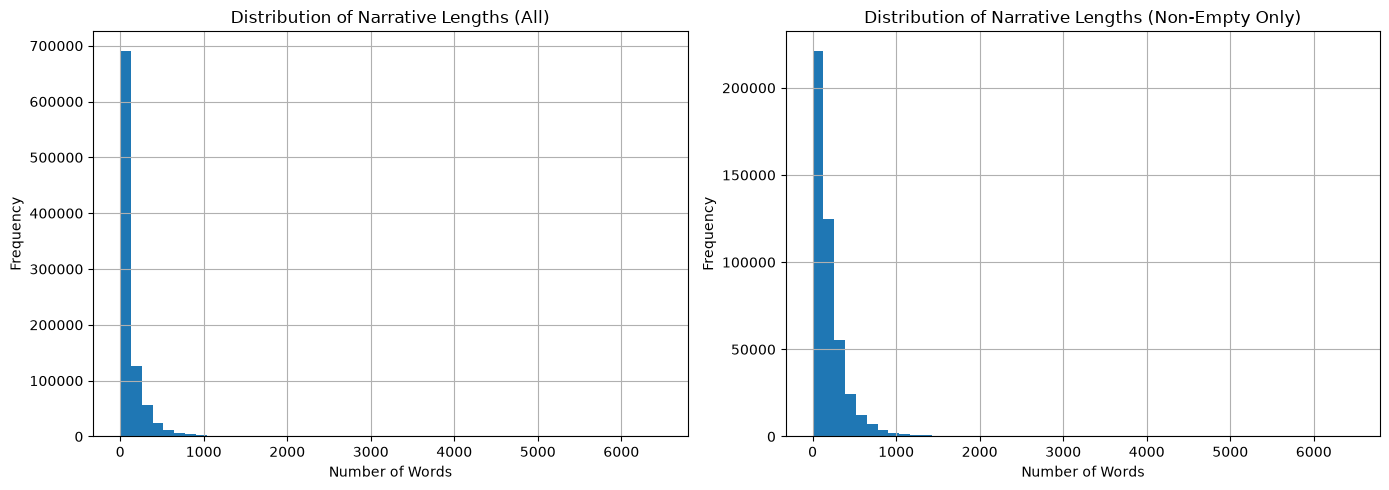


📏 Extreme cases:
   Very short (≤10 words): 473,993
   Very long (≥500 words): 32,535

📊 Average narrative length by product:
Product_clean
Credit card         93.0
Money transfer     110.5
Personal loan      107.7
Savings account    105.9
Name: narrative_length, dtype: float64


In [10]:
# Step 1: Create a column for narrative word count
# fillna('') replaces empty values with empty string
# apply() runs the function on each row
# split() breaks text into words, len() counts them
df_filtered['narrative_length'] = df_filtered['Consumer complaint narrative'].fillna('').apply(
    lambda x: len(str(x).split())
)

# Step 2: Calculate summary statistics
# describe() gives: count, mean, std, min, 25%, 50% (median), 75%, max
print("📝 Narrative Length Statistics:")
print(df_filtered['narrative_length'].describe())

# Step 3: Count how many complaints have empty narratives (length = 0)
zero_narratives = (df_filtered['narrative_length'] == 0).sum()
print(f"\n📊 Complaints with empty narratives: {zero_narratives:,} ({zero_narratives/len(df_filtered)*100:.2f}%)")

# Step 4: Create visualizations to see the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: All narratives (including zeros)
df_filtered['narrative_length'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution of Narrative Lengths (All)')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# Right chart: Only narratives with text (excluding zeros)
# This gives us a clearer picture of actual narrative lengths
df_filtered[df_filtered['narrative_length'] > 0]['narrative_length'].hist(bins=50, ax=axes[1])
axes[1].set_title('Distribution of Narrative Lengths (Non-Empty Only)')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Step 5: Check for extreme cases
short = df_filtered[df_filtered['narrative_length'] <= 10].shape[0]  # Very short
long = df_filtered[df_filtered['narrative_length'] >= 500].shape[0]  # Very long

print(f"\n📏 Extreme cases:")
print(f"   Very short (≤10 words): {short:,}")
print(f"   Very long (≥500 words): {long:,}")

# Step 6: Show average length per product
print(f"\n📊 Average narrative length by product:")
print(df_filtered.groupby('Product_clean')['narrative_length'].mean().round(1))

In [11]:
# Step 1: Get complaints that have narratives
df_with_narrative = df_filtered[df_filtered['Consumer complaint narrative'].notna()]

print(f"📝 Total complaints with narratives: {len(df_with_narrative):,}")
print(f"📊 Sample of Consumer Complaint Narratives:")
print("=" * 80)

# Step 2: Randomly sample 5 complaints
sample_narratives = df_with_narrative.sample(5)

# Step 3: Display each sample with its product and issue
for idx, row in sample_narratives.iterrows():
    print(f"\nProduct: {row['Product_clean']}")
    print(f"Issue: {row['Issue']}")
    print(f"Sub-issue: {row['Sub-issue']}")
    print(f"Narrative (first 300 characters):")
    print(row['Consumer complaint narrative'][:300] + "...")
    print("-" * 80)

# Step 4: Check the shortest and longest narratives
print(f"\n📏 Shortest narrative:")
shortest_idx = df_with_narrative['narrative_length'].idxmin()
print(f"Length: {df_with_narrative.loc[shortest_idx, 'narrative_length']} words")
print(f"Text: {df_with_narrative.loc[shortest_idx, 'Consumer complaint narrative'][:100]}...")

print(f"\n📏 Longest narrative:")
longest_idx = df_with_narrative['narrative_length'].idxmax()
print(f"Length: {df_with_narrative.loc[longest_idx, 'narrative_length']} words")
print(f"Text: {df_with_narrative.loc[longest_idx, 'Consumer complaint narrative'][:100]}...")

📝 Total complaints with narratives: 456,218
📊 Sample of Consumer Complaint Narratives:

Product: Savings account
Issue: Managing an account
Sub-issue: Deposits and withdrawals
Narrative (first 300 characters):
On XX/XX/2019, I deposited a check made to my wife for {$3100.00}. Bank of America put a 9 day hold on the check and will not tell me why. We have been banking with them for 35 years and have never had a hold put on before. There have been zero issue on our end with the account....
--------------------------------------------------------------------------------

Product: Credit card
Issue: Problem with a purchase shown on your statement
Sub-issue: Credit card company isn't resolving a dispute about a purchase on your statement
Narrative (first 300 characters):
Bank of America credit card is DISGUSTING! I purchased renters insurance for one year with XXXX XXXX ( through XXXX and a HUGE MISTAKE! ) on XX/XX/XXXX for {$140.00}. The agent charged me and stated I would get the declarat

✅ Removed 471,131 complaints with empty narratives
📊 Remaining complaints: 456,218
📊 Removed percentage: 50.8%

📊 Product Distribution (After Removing Empty Narratives):
Product_clean
Credit card        189334
Savings account    140319
Money transfer      98685
Personal loan       27880
Name: count, dtype: int64


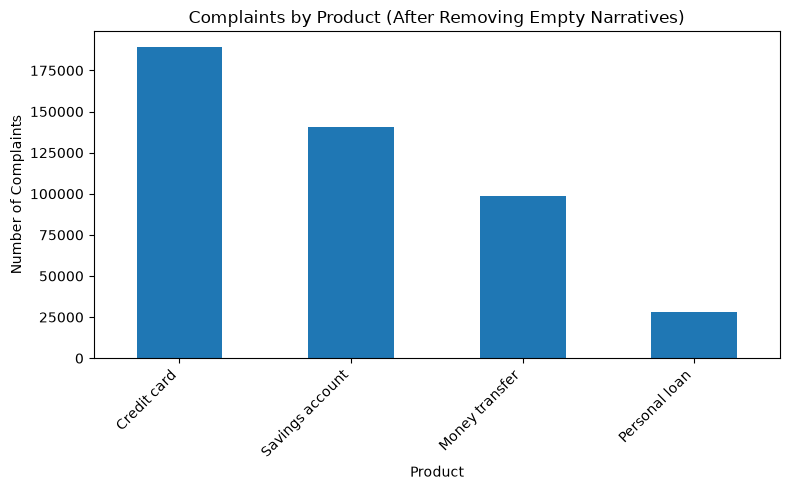


📊 Percentage breakdown by product:
Product_clean
Credit card        41.50
Savings account    30.76
Money transfer     21.63
Personal loan       6.11
Name: count, dtype: float64


In [12]:
# Step 1: Keep only rows with non-empty narratives
df_clean = df_filtered[df_filtered['Consumer complaint narrative'].notna()].copy()

# Step 2: Show what we removed
removed_count = len(df_filtered) - len(df_clean)
print(f"✅ Removed {removed_count:,} complaints with empty narratives")
print(f"📊 Remaining complaints: {len(df_clean):,}")
print(f"📊 Removed percentage: {removed_count/len(df_filtered)*100:.1f}%")

# Step 3: Check the new distribution by product
clean_counts = df_clean['Product_clean'].value_counts()
print("\n📊 Product Distribution (After Removing Empty Narratives):")
print(clean_counts)

# Step 4: Visualize the new distribution
plt.figure(figsize=(8, 5))
clean_counts.plot(kind='bar')
plt.title('Complaints by Product (After Removing Empty Narratives)')
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Step 5: Show percentage breakdown
print("\n📊 Percentage breakdown by product:")
print((clean_counts / len(df_clean) * 100).round(2))

In [14]:
import re

def clean_text(text):
    """
    Clean complaint narrative text.
    
    Steps:
    1. Convert to lowercase - makes text consistent
    2. Remove special characters - keep only letters, numbers, spaces
    3. Remove extra spaces - clean up whitespace
    4. Remove common boilerplate phrases - generic text that adds no value
    """
    # Check if text is empty
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Step 1: Lowercase everything
    text = text.lower()
    
    # Step 2: Remove special characters (keep only letters, numbers, spaces)
    # [^a-zA-Z0-9\s] means "anything that is NOT a letter, number, or space"
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # Step 3: Remove extra spaces (multiple spaces become one)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 4: Remove common boilerplate phrases
    # These are phrases that appear at the start of many complaints
    boilerplate_patterns = [
        r'i am writing to file a complaint',
        r'i would like to file a complaint',
        r'this is a complaint about',
        r'i wish to complain about'
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, '', text)
    
    # Step 5: Clean up any remaining extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Step 6: Apply the cleaning function to create a new column
print("🔄 Cleaning complaint narratives...")
df_clean['cleaned_narrative'] = df_clean['Consumer complaint narrative'].apply(clean_text)
print("✅ Text cleaning complete!")

# Step 7: Show before and after comparison
print(f"\n📝 Original sample:")
print(df_clean['Consumer complaint narrative'].iloc[0][:200] + "...")
print(f"\n📝 Cleaned sample:")
print(df_clean['cleaned_narrative'].iloc[0][:200] + "...")

# Step 8: Check new word counts after cleaning
df_clean['cleaned_length'] = df_clean['cleaned_narrative'].apply(lambda x: len(str(x).split()))
print(f"\n📊 Cleaned narrative statistics:")
print(df_clean['cleaned_length'].describe())

# Step 9: Show how much text was removed
avg_original = df_clean['narrative_length'].mean()
avg_cleaned = df_clean['cleaned_length'].mean()
reduction = (1 - avg_cleaned/avg_original) * 100
print(f"\n📊 Average length comparison:")
print(f"   Original: {avg_original:.1f} words")
print(f"   Cleaned: {avg_cleaned:.1f} words")
print(f"   Reduction: {reduction:.1f}%")

🔄 Cleaning complaint narratives...
✅ Text cleaning complete!

📝 Original sample:
A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unaut...

📝 Cleaned sample:
a xxxx xxxx card was opened under my name by a fraudster i received a notice from xxxx that an account was just opened under my name i reached out to xxxx xxxx to state that this activity was unauthor...

📊 Cleaned narrative statistics:
count    456218.000000
mean        200.856637
std         222.483250
min           1.000000
25%          81.000000
50%         134.000000
75%         249.000000
max        6469.000000
Name: cleaned_length, dtype: float64

📊 Average length comparison:
   Original: 204.7 words
   Cleaned: 200.9 words
   Reduction: 1.9%


In [15]:
# Step 1: Save the cleaned data
output_path = '../data/processed/filtered_complaints.csv'
df_clean.to_csv(output_path, index=False)

print(f"✅ Cleaned data saved to: {output_path}")
print(f"📊 Final shape: {df_clean.shape[0]:,} rows and {df_clean.shape[1]} columns")
print(f"📋 Products: {df_clean['Product_clean'].unique().tolist()}")

# Step 2: Save a small sample for testing (optional but useful)
sample_path = '../data/processed/filtered_complaints_sample.csv'
df_sample = df_clean.sample(min(10000, len(df_clean)))
df_sample.to_csv(sample_path, index=False)
print(f"\n📊 Sample saved to: {sample_path} ({len(df_sample):,} rows)")

# Step 3: Create a summary of Task 1
print("\n" + "=" * 50)
print("📝 SUMMARY OF TASK 1")
print("=" * 50)
print(f"Step 1: Loaded full CFPB dataset")
print(f"   - Total complaints: {len(df):,}")
print(f"   - Found {len(df['Product'].unique())} product categories")
print(f"\nStep 2: Filtered to 4 target products")
print(f"   - Target products: Credit card, Personal loan, Savings account, Money transfer")
print(f"   - Filtered complaints: {len(df_filtered):,}")
print(f"\nStep 3: Removed empty narratives")
print(f"   - Removed: {len(df_filtered) - len(df_clean):,} ({removed_count/len(df_filtered)*100:.1f}%)")
print(f"   - Remaining: {len(df_clean):,}")
print(f"\nStep 4: Cleaned text narratives")
print(f"   - Average original length: {avg_original:.1f} words")
print(f"   - Average cleaned length: {avg_cleaned:.1f} words")
print(f"   - Text reduction: {reduction:.1f}%")
print(f"\n📂 Final file saved: {output_path}")
print("=" * 50)

OSError: [Errno 28] No space left on device